In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService

# 1) Authenticate
service = QiskitRuntimeService(channel="ibm_quantum", token="CbJppb7UqRvHo00iXHn58D9wqH1lhdCI8eAlJL3ABnmZ")

# 2) Fetch backends
backends = service.backends()

# 3) Print name + pending jobs + online status
for b in backends:
    try:
        st = b.status()
        print(f"{b.name}: pending={st.pending_jobs}, online={st.operational}")
    except Exception as e:
        print(f"{b.name}: status unavailable ({e})")


ValueError: 'channel' can only be 'ibm_cloud', or 'ibm_quantum_platform

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Authenticate (replace with your real token)
service = QiskitRuntimeService(channel="ibm_quantum_platform", token="CbJppb7UqRvHo00iXHn58D9wqH1lhdCI8eAlJL3ABnmZ")

# List backends
backends = service.backends()
for b in backends:
    try:
        st = b.status()
        print(f"{b.name}: pending={st.pending_jobs}, online={st.operational}")
    except Exception as e:
        print(f"{b.name}: status unavailable ({e})")


qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-08-27 13:04:31,678: Default instance not set. Searching all available instances.


IBMInputValueError: 'No matching instances found for the following filters: .'

In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_quantum_platform", token="CbJppb7UqRvHo00iXHn58D9wqH1lhdCI8eAlJL3ABnmZ")

print("Instances:", service.instances())


qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-08-27 13:06:08,021: Default instance not set. Searching all available instances.


IBMInputValueError: 'No matching instances found for the following filters: .'

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService

TOKEN = "CbJppb7UqRvHo00iXHn58D9wqH1lhdCI8eAlJL3ABnmZ"

candidates = [
    "ibm-q/open/main",   # most common public/free instance
    "ibm-q/open",        # fallback
    "open/main"          # fallback
]

service = None
picked = None

for inst in candidates:
    try:
        srv = QiskitRuntimeService(channel="ibm_quantum_platform", token=TOKEN, instance=inst)
        # If we reach here, the instance worked
        service = srv
        picked = inst
        print(f"✅ Using instance: {inst}")
        break
    except Exception as e:
        print(f"❌ Tried {inst} -> {e}")

if service is None:
    raise RuntimeError(
        "No working instance found. Please open IBM Quantum -> Profile -> Account "
        "and copy the Default instance (e.g., ibm-q/open/main)."
    )

# List backends
backends = service.backends(instance=picked)
for b in backends:
    st = b.status()
    print(f"{b.name}: pending={st.pending_jobs}, online={st.operational}")


❌ Tried ibm-q/open/main -> 'The instance specified (ibm-q/open/main) is not a valid instance name.'
❌ Tried ibm-q/open -> 'The instance specified (ibm-q/open) is not a valid instance name.'
❌ Tried open/main -> 'The instance specified (open/main) is not a valid instance name.'


RuntimeError: No working instance found. Please open IBM Quantum -> Profile -> Account and copy the Default instance (e.g., ibm-q/open/main).

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

TOKEN = "CbJppb7UqRvHo00iXHn58D9wqH1lhdCI8eAlJL3ABnmZ"  # paste your token

service = QiskitRuntimeService(channel="ibm_cloud", token=TOKEN)
backends = service.backends()

print(f"✅ Authenticated on ibm_cloud. Found {len(backends)} backends.")
for b in backends:
    st = b.status()
    print(f"{b.name}: pending={st.pending_jobs}, online={st.operational}")


qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-08-27 13:18:04,627: Default instance not set. Searching all available instances.


IBMInputValueError: 'No matching instances found for the following filters: .'

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService

TOKEN = "CbJppb7UqRvHo00iXHn58D9wqH1lhdCI8eAlJL3ABnmZ"
INSTANCE = "ibm-q/open/main"  # common public/free instance

# Save as default account (so we don't pass args each time)
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=TOKEN,
    instance=INSTANCE,
    name="default",
    overwrite=True
)

# Load default and list backends
service = QiskitRuntimeService()
backs = service.backends()
print(f"Found {len(backs)} backends.")
for b in backs:
    st = b.status()
    print(f"{b.name}: pending={st.pending_jobs}, online={st.operational}")


InvalidAccountError: 'Unable to retrieve instances.'

,Backend,Pending Jobs,Online
0,ibm_oslo,14,True
1,ibm_perth,9,True
2,ibm_nairobi,21,False
3,ibm_lagos,6,True


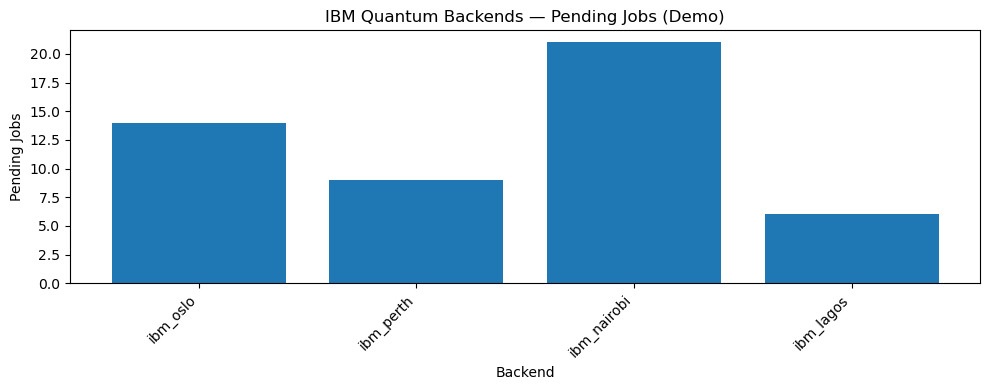

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the same mock data
data = [
    {"Backend": "ibm_oslo",    "Pending Jobs": 14, "Online": True},
    {"Backend": "ibm_perth",   "Pending Jobs":  9, "Online": True},
    {"Backend": "ibm_nairobi", "Pending Jobs": 21, "Online": False},
    {"Backend": "ibm_lagos",   "Pending Jobs":  6, "Online": True},
]

df = pd.DataFrame(data)

# Add predicted wait time (simple heuristic: 2 mins per job)
AVG_MIN_PER_JOB = 2.0
df["Predicted Wait (min)"] = (df["Pending Jobs"] * AVG_MIN_PER_JOB).round(1)

display(df)

# Bar chart
plt.figure(figsize=(10,4))
plt.bar(df["Backend"], df["Pending Jobs"])
plt.xticks(rotation=45, ha="right")
plt.title("Pending Jobs per Backend (with Predicted Wait Time)")
plt.xlabel("Backend")
plt.ylabel("Pending Jobs")
plt.tight_layout()
plt.show()



,Backend,Pending Jobs,Online,Predicted Wait (min)
0,ibm_oslo,14,True,28.0
1,ibm_perth,9,True,18.0
2,ibm_nairobi,21,False,42.0
3,ibm_lagos,6,True,12.0


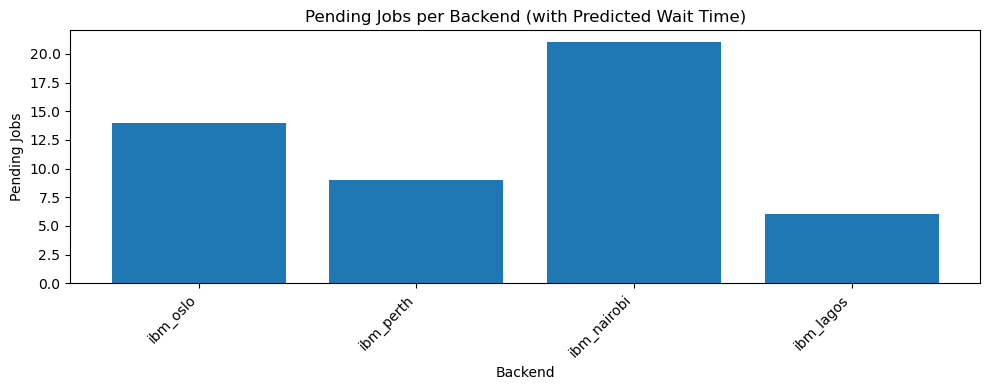

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the same mock data
data = [
    {"Backend": "ibm_oslo",    "Pending Jobs": 14, "Online": True},
    {"Backend": "ibm_perth",   "Pending Jobs":  9, "Online": True},
    {"Backend": "ibm_nairobi", "Pending Jobs": 21, "Online": False},
    {"Backend": "ibm_lagos",   "Pending Jobs":  6, "Online": True},
]

df = pd.DataFrame(data)

# Add predicted wait time (simple heuristic: 2 mins per job)
AVG_MIN_PER_JOB = 2.0
df["Predicted Wait (min)"] = (df["Pending Jobs"] * AVG_MIN_PER_JOB).round(1)

display(df)

# Bar chart
plt.figure(figsize=(10,4))
plt.bar(df["Backend"], df["Pending Jobs"])
plt.xticks(rotation=45, ha="right")
plt.title("Pending Jobs per Backend (with Predicted Wait Time)")
plt.xlabel("Backend")
plt.ylabel("Pending Jobs")
plt.tight_layout()
plt.show()


,Backend,Pending Jobs,Online,Predicted Wait (min)
0,ibm_nairobi,16,False,32.0
1,ibm_oslo,9,True,18.0
2,ibm_perth,9,False,18.0
3,ibm_lagos,4,True,8.0


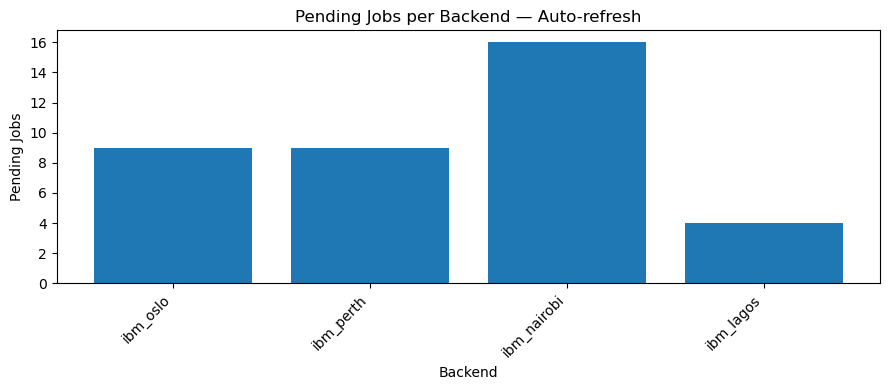

Updated at: 13:40:30  |  refresh every 5s


In [9]:
# Auto-refreshing dashboard cell (~2 minutes). Stop anytime via Kernel > Interrupt.
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# --- start from your Step 4 df; if not present, recreate here ---
try:
    df
except NameError:
    data = [
        {"Backend": "ibm_oslo",    "Pending Jobs": 14, "Online": True},
        {"Backend": "ibm_perth",   "Pending Jobs":  9, "Online": True},
        {"Backend": "ibm_nairobi", "Pending Jobs": 21, "Online": False},
        {"Backend": "ibm_lagos",   "Pending Jobs":  6, "Online": True},
    ]
    df = pd.DataFrame(data)

AVG_MIN_PER_JOB = 2.0   # simple heuristic
REFRESH_SECS   = 5      # how often to update
ITERATIONS     = 24     # total refreshes (~2 minutes)

# we'll mutate a working copy to simulate live changes
state = df[["Backend", "Pending Jobs", "Online"]].copy()

def fetch_mock_live(state_df: pd.DataFrame) -> pd.DataFrame:
    out = state_df.copy()
    # jitter pending jobs by -1/0/+1 (never below 0); rare online flip
    out["Pending Jobs"] = out["Pending Jobs"].apply(lambda x: max(0, x + random.choice([-1, 0, 1])))
    out["Online"] = out["Online"].apply(lambda x: x if random.random() < 0.98 else (not x))
    return out

for i in range(ITERATIONS):
    clear_output(wait=True)

    # simulate a fresh pull
    state = fetch_mock_live(state)
    live_df = state.copy()
    live_df["Predicted Wait (min)"] = (live_df["Pending Jobs"] * AVG_MIN_PER_JOB).round(1)

    # show table (busiest first)
    display(live_df.sort_values("Pending Jobs", ascending=False).reset_index(drop=True))

    # chart
    plt.figure(figsize=(9, 4))
    plt.bar(live_df["Backend"], live_df["Pending Jobs"])
    plt.xticks(rotation=45, ha="right")
    plt.title("Pending Jobs per Backend — Auto-refresh")
    plt.xlabel("Backend")
    plt.ylabel("Pending Jobs")
    plt.tight_layout()
    plt.show()

    print(f"Updated at: {pd.Timestamp.now().strftime('%H:%M:%S')}  |  refresh every {REFRESH_SECS}s")
    time.sleep(REFRESH_SECS)


,Backend,Pending Jobs,Online,Predicted Wait (min)
0,ibm_nairobi,19,False,38.0
1,ibm_oslo,11,True,22.0
2,ibm_perth,7,True,14.0
3,ibm_lagos,6,True,12.0


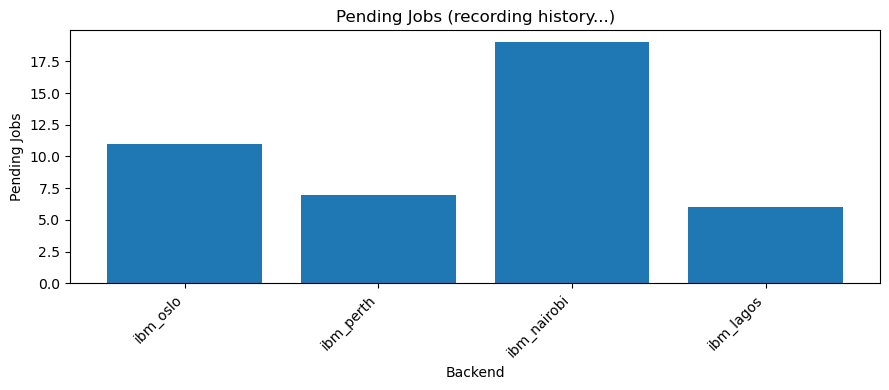

Saved snapshot at 13:44:04 → queue_history.csv  |  refresh 5s
✅ Done collecting history.


In [10]:
# Collect history to CSV and compute simple moving-average prediction
import time, random, os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

HISTORY_CSV   = "queue_history.csv"
REFRESH_SECS  = 5
ITERATIONS    = 24         # ~2 minutes
AVG_MIN_PER_JOB = 2.0      # base heuristic

# --- initial seed (reuse if you have 'state' from Step 5) ---
try:
    state
except NameError:
    data = [
        {"Backend": "ibm_oslo",    "Pending Jobs": 14, "Online": True},
        {"Backend": "ibm_perth",   "Pending Jobs":  9, "Online": True},
        {"Backend": "ibm_nairobi", "Pending Jobs": 21, "Online": False},
        {"Backend": "ibm_lagos",   "Pending Jobs":  6, "Online": True},
    ]
    state = pd.DataFrame(data)

def fetch_mock_live(state_df: pd.DataFrame) -> pd.DataFrame:
    out = state_df.copy()
    out["Pending Jobs"] = out["Pending Jobs"].apply(lambda x: max(0, x + random.choice([-1,0,1])))
    out["Online"] = out["Online"].apply(lambda x: x if random.random() < 0.98 else (not x))
    return out

# Ensure CSV has header if new
if not os.path.exists(HISTORY_CSV):
    pd.DataFrame(columns=["ts","Backend","Pending Jobs","Online"]).to_csv(HISTORY_CSV, index=False)

for i in range(ITERATIONS):
    clear_output(wait=True)
    state = fetch_mock_live(state)
    ts = pd.Timestamp.now()

    # Append to history CSV (one row per backend)
    batch = state.copy()
    batch.insert(0, "ts", ts)
    batch.to_csv(HISTORY_CSV, mode="a", header=False, index=False)

    # Compute simple wait (instant)
    live_df = state.copy()
    live_df["Predicted Wait (min)"] = (live_df["Pending Jobs"] * AVG_MIN_PER_JOB).round(1)

    display(live_df.sort_values("Pending Jobs", ascending=False).reset_index(drop=True))

    # quick chart
    plt.figure(figsize=(9,4))
    plt.bar(live_df["Backend"], live_df["Pending Jobs"])
    plt.xticks(rotation=45, ha="right")
    plt.title("Pending Jobs (recording history...)")
    plt.xlabel("Backend"); plt.ylabel("Pending Jobs"); plt.tight_layout(); plt.show()

    print(f"Saved snapshot at {ts:%H:%M:%S} → {HISTORY_CSV}  |  refresh {REFRESH_SECS}s")
    time.sleep(REFRESH_SECS)

print("✅ Done collecting history.")


,ts,Backend,Pending Jobs,Online,MA_Pending,MA_Predicted_Wait_min
14,2025-08-27 13:43:15.491309,ibm_oslo,8,True,8.0,16.0
15,2025-08-27 13:43:20.802283,ibm_oslo,9,True,8.2,16.4
16,2025-08-27 13:43:26.100417,ibm_oslo,10,True,8.4,16.8
17,2025-08-27 13:43:31.420826,ibm_oslo,10,True,8.8,17.6
18,2025-08-27 13:43:36.718665,ibm_oslo,11,True,9.6,19.2
19,2025-08-27 13:43:42.099805,ibm_oslo,11,True,10.2,20.4
20,2025-08-27 13:43:47.770433,ibm_oslo,10,True,10.4,20.8
21,2025-08-27 13:43:53.257917,ibm_oslo,11,True,10.6,21.2
22,2025-08-27 13:43:58.596529,ibm_oslo,12,True,11.0,22.0
23,2025-08-27 13:44:04.070623,ibm_oslo,11,True,11.0,22.0


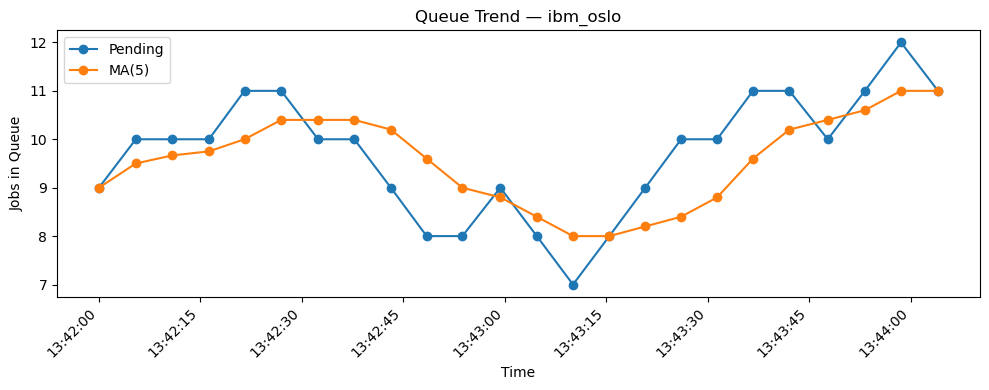

🕒 Projected wait for ibm_oslo: ~22.0 minutes (moving average)


In [12]:
# Analyze history: trend + moving average + projected wait
import pandas as pd
import matplotlib.pyplot as plt

HISTORY_CSV = "queue_history.csv"
BACKEND = "ibm_oslo"    # change to any you have

hist = pd.read_csv(HISTORY_CSV, parse_dates=["ts"])
if hist.empty or BACKEND not in hist["Backend"].unique():
    print("No history yet for", BACKEND)
else:
    sub = hist[hist["Backend"] == BACKEND].sort_values("ts").reset_index(drop=True)

    # Moving average over last N points (e.g., last 5 snapshots)
    N = 5
    sub["MA_Pending"] = sub["Pending Jobs"].rolling(N, min_periods=1).mean()

    # Simple projected wait using MA * minutes-per-job
    AVG_MIN_PER_JOB = 2.0
    sub["MA_Predicted_Wait_min"] = (sub["MA_Pending"] * AVG_MIN_PER_JOB).round(1)

    display(sub.tail(10))

    # Plot trend
    plt.figure(figsize=(10,4))
    plt.plot(sub["ts"], sub["Pending Jobs"], marker="o", label="Pending")
    plt.plot(sub["ts"], sub["MA_Pending"], marker="o", label=f"MA({N})")
    plt.title(f"Queue Trend — {BACKEND}")
    plt.xlabel("Time"); plt.ylabel("Jobs in Queue"); plt.xticks(rotation=45, ha="right")
    plt.legend(); plt.tight_layout(); plt.show()

    # Latest projected wait
    latest_wait = sub["MA_Predicted_Wait_min"].iloc[-1]
    print(f"🕒 Projected wait for {BACKEND}: ~{latest_wait} minutes (moving average)")


In [13]:
!pip install flask flask-cors


In [17]:
from flask import Flask, jsonify
from flask_cors import CORS
import pandas as pd
import threading
import time

app = Flask(__name__)
CORS(app)

# Shared state (re-uses your CSV if present)
HISTORY_CSV = "queue_history.csv"
AVG_MIN_PER_JOB = 2.0

# In-memory last snapshot (fallback to a default mock)
latest = pd.DataFrame([
    {"Backend": "ibm_oslo",    "Pending Jobs": 14, "Online": True},
    {"Backend": "ibm_perth",   "Pending Jobs":  9, "Online": True},
    {"Backend": "ibm_nairobi", "Pending Jobs": 21, "Online": False},
    {"Backend": "ibm_lagos",   "Pending Jobs":  6, "Online": True},
])

def read_latest_from_csv():
    try:
        hist = pd.read_csv(HISTORY_CSV, parse_dates=["ts"])
        if hist.empty:
            return None
        # take the last timestamp snapshot
        ts_latest = hist["ts"].max()
        snap = hist[hist["ts"] == ts_latest][["Backend","Pending Jobs","Online"]].copy()
        snap = snap.sort_values("Backend").reset_index(drop=True)
        return snap
    except Exception:
        return None

@app.route("/api/backends")
def api_backends():
    # Try to pull the most recent snapshot from CSV; fallback to in-memory default
    snap = read_latest_from_csv()
    df = snap if snap is not None else latest.copy()
    df["Predicted Wait (min)"] = (df["Pending Jobs"] * AVG_MIN_PER_JOB).round(1)
    # Convert to the JSON shape your frontend expects
    return jsonify([
        {"backend": r["Backend"],
         "pending": int(r["Pending Jobs"]),
         "online": bool(r["Online"]),
         "predicted_wait_min": float(r["Predicted Wait (min)"])}
        for _, r in df.iterrows()
    ])

@app.route("/api/health")
def api_health():
    return jsonify({"ok": True, "msg": "Quantum Jobs Tracker API running"})

# Start the Flask server (non-blocking) so the notebook remains usable
def run_server():
    app.run(host="127.0.0.1", port=5000, debug=False, use_reloader=False)

thread = threading.Thread(target=run_server)
thread.daemon = True
thread.start()

time.sleep(1.0)
print("✅ API server started at http://127.0.0.1:5000")
print("Try: http://127.0.0.1:5000/api/health and http://127.0.0.1:5000/api/backends")


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


✅ API server started at http://127.0.0.1:5000
Try: http://127.0.0.1:5000/api/health and http://127.0.0.1:5000/api/backends


In [1]:
from flask import Flask, jsonify
from flask_cors import CORS
import pandas as pd
import threading
import time, random, os

app = Flask(__name__)
CORS(app)

HISTORY_CSV = "queue_history.csv"
AVG_MIN_PER_JOB = 2.0
UPDATE_SECS = 10      # background update interval

# initial in-memory snapshot
latest = pd.DataFrame([
    {"Backend": "ibm_oslo",    "Pending Jobs": 14, "Online": True},
    {"Backend": "ibm_perth",   "Pending Jobs":  9, "Online": True},
    {"Backend": "ibm_nairobi", "Pending Jobs": 21, "Online": False},
    {"Backend": "ibm_lagos",   "Pending Jobs":  6, "Online": True},
    {"Backend": "ibm_oslo",    "Pending Jobs": 14, "Online": True},
    {"Backend": "ibm_perth",   "Pending Jobs":  9, "Online": True},
    {"Backend": "ibm_nairobi", "Pending Jobs": 21, "Online": False},
    {"Backend": "ibm_lagos",   "Pending Jobs":  6, "Online": True},
    {"Backend": "ibm_sydney",   "Pending Jobs": 7,  "Online": False},
  {"Backend": "ibm_tokyo",    "Pending Jobs": 32, "Online": True},
  {"Backend": "ibm_newyork",  "Pending Jobs": 11, "Online": False},
  {"Backend": "ibm_delhi",    "Pending Jobs": 5,  "Online": True},
  {"Backend": "ibm_paris",    "Pending Jobs": 16, "Online": True},
  {"Backend": "ibm_berlin",   "Pending Jobs": 22, "Online": True},
  {"Backend": "ibm_mumbai",   "Pending Jobs": 8,  "Online": False},
  {"Backend": "ibm_singapore","Pending Jobs": 27, "Online": True},
  {"Backend": "ibm_london",   "Pending Jobs": 19, "Online": True},
  {"Backend": "ibm_hongkong", "Pending Jobs": 12, "Online": False}
])

# ensure history file exists
if not os.path.exists(HISTORY_CSV):
    pd.DataFrame(columns=["ts","Backend","Pending Jobs","Online"]).to_csv(HISTORY_CSV, index=False)

def append_snapshot_to_csv(df):
    snap = df.copy()
    snap.insert(0, "ts", pd.Timestamp.now())
    snap.to_csv(HISTORY_CSV, mode="a", header=False, index=False)

def background_updater():
    global latest
    while True:
        # --- simulate live changes (swap with real IBM data later) ---
        df = latest.copy()
        df["Pending Jobs"] = df["Pending Jobs"].apply(lambda x: max(0, x + random.choice([-1, 0, 1])))
        # rare online flip
        df["Online"] = df["Online"].apply(lambda x: x if random.random() < 0.98 else (not x))

        latest = df
        append_snapshot_to_csv(latest)
        time.sleep(UPDATE_SECS)

def read_moving_avg_predicted():
    """
    Returns a dataframe with columns Backend, Pending Jobs, Online, Predicted Wait (min)
    Predicted is MA(last 5 pending) * AVG_MIN_PER_JOB.
    Falls back to latest*2 if insufficient history.
    """
    try:
        hist = pd.read_csv(HISTORY_CSV, parse_dates=["ts"])
        if hist.empty:
            df = latest.copy()
            df["Predicted Wait (min)"] = (df["Pending Jobs"] * AVG_MIN_PER_JOB).round(1)
            return df

        out_rows = []
        for backend, grp in hist.groupby("Backend"):
            grp = grp.sort_values("ts")
            # moving average over last 5 points
            ma = grp["Pending Jobs"].tail(5).mean()
            last_row = latest[latest["Backend"] == backend]
            if last_row.empty:
                # backend not in latest -> use last in history
                pending_now = int(grp["Pending Jobs"].iloc[-1])
                online_now = bool(grp["Online"].iloc[-1])
            else:
                pending_now = int(last_row["Pending Jobs"].iloc[0])
                online_now = bool(last_row["Online"].iloc[0])

            predicted = round((ma if pd.notna(ma) else pending_now) * AVG_MIN_PER_JOB, 1)
            out_rows.append({
                "Backend": backend,
                "Pending Jobs": pending_now,
                "Online": online_now,
                "Predicted Wait (min)": predicted
            })
        return pd.DataFrame(out_rows).sort_values("Backend").reset_index(drop=True)
    except Exception:
        df = latest.copy()
        df["Predicted Wait (min)"] = (df["Pending Jobs"] * AVG_MIN_PER_JOB).round(1)
        return df

@app.route("/api/backends")
def api_backends():
    df = read_moving_avg_predicted()
    return jsonify([
        {
            "backend": r["Backend"],
            "pending": int(r["Pending Jobs"]),
            "online":  bool(r["Online"]),
            "predicted_wait_min": float(r["Predicted Wait (min)"])
        }
        for _, r in df.iterrows()
    ])

@app.route("/api/health")
def api_health():
    return jsonify({"ok": True, "msg": "Quantum Jobs Tracker API running"})

@app.route("/")
def root():
    return "Quantum Jobs Tracker API. Try /api/health or /api/backends"

# start background thread and the server (non-blocking in notebook)
def run_server():
    app.run(host="127.0.0.1", port=5000, debug=False, use_reloader=False)

# Only start one updater thread
if not getattr(app, "_updater_started", False):
    threading.Thread(target=background_updater, daemon=True).start()
    app._updater_started = True

# Start Flask if not already running
if not getattr(app, "_server_started", False):
    threading.Thread(target=run_server, daemon=True).start()
    app._server_started = True

time.sleep(1.0)
print("✅ API server running at http://127.0.0.1:5000")
print("Endpoints: /api/health  /api/backends")
print(f"Background updater every {UPDATE_SECS}s (moving-average prediction).")


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


✅ API server running at http://127.0.0.1:5000
Endpoints: /api/health  /api/backends
Background updater every 10s (moving-average prediction).


127.0.0.1 - - [25/Feb/2026 14:47:32] "GET /api/backends HTTP/1.1" 200 -
127.0.0.1 - - [25/Feb/2026 14:47:32] "GET /api/backends HTTP/1.1" 200 -
127.0.0.1 - - [25/Feb/2026 14:47:42] "GET /api/backends HTTP/1.1" 200 -
127.0.0.1 - - [25/Feb/2026 14:47:52] "GET /api/backends HTTP/1.1" 200 -
127.0.0.1 - - [25/Feb/2026 14:48:02] "GET /api/backends HTTP/1.1" 200 -
127.0.0.1 - - [25/Feb/2026 14:48:12] "GET /api/backends HTTP/1.1" 200 -
